In [50]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak

In [51]:
f = "/home/sawini-jana/hep/MG5_aMC_v3_7_1/dihiggs_output_6.5TeV.root"
file = uproot.open(f)
print("Available keys:", file.keys())
tree_h = file["Delphes"]
f_qcd = uproot.open("/home/sawini-jana/hep/MG5_aMC_v3_7_1/qcd_output_6.5TeV.root")
tree_qcd = f_qcd["Delphes"]
print("Available keys:", f_qcd.keys())

Available keys: ['ProcessID0;1', 'Delphes;1']
Available keys: ['ProcessID0;1', 'Delphes;1']


In [73]:
for branch in tree_h.keys():
    if "Soft" in branch:
        print(branch)

GenJet/GenJet.SoftDroppedJet
GenJet/GenJet.SoftDroppedSubJet1
GenJet/GenJet.SoftDroppedSubJet2
GenJet/GenJet.SoftDroppedP4[5]
GenJet/GenJet.NSubJetsSoftDropped
Jet/Jet.SoftDroppedJet
Jet/Jet.SoftDroppedSubJet1
Jet/Jet.SoftDroppedSubJet2
Jet/Jet.SoftDroppedP4[5]
Jet/Jet.NSubJetsSoftDropped
FatJet/FatJet.SoftDroppedJet
FatJet/FatJet.SoftDroppedSubJet1
FatJet/FatJet.SoftDroppedSubJet2
FatJet/FatJet.SoftDroppedP4[5]
FatJet/FatJet.NSubJetsSoftDropped


In [89]:
import numpy as np
a = np.array([1,2,-2,-3,-4])
tau1 = ak.to_numpy(tree_h["Jet.Tau[5]"].array()[:,0,0])
tau2 = ak.to_numpy(tree_h["Jet.Tau[5]"].array()[:,0,1])
tau21 = np.full_like(tau1, -1.0, dtype=float)
np.divide(tau2, tau1, out=tau21, where=tau1 > 0)
print(r"Jet ${\tau}_{21}$")
for i in tau21[:30]:
        print(i, end = " ")
print()
tau1 = ak.to_numpy(tree_h["FatJet.Tau[5]"].array()[:,0,0])
tau2 = ak.to_numpy(tree_h["FatJet.Tau[5]"].array()[:,0,1])
tau21 = np.full_like(tau1, -1.0, dtype=float)
np.divide(tau2, tau1, out=tau21, where=tau1 > 0)
print(r"FatJet ${\tau}_{21}$")
for i in tau21[:30]:
        print(i, end = " ")
print()
print(tree_h["FatJet.SoftDroppedP4[5]"].interpretation)
arr = tree_h["FatJet.SoftDroppedP4[5]"].array()
print(ak.type(arr))
print(arr[1,1])

Jet ${\tau}_{21}$
0.7537375092506409 0.7821972966194153 0.17696936428546906 0.18551738560199738 0.5066614747047424 0.15660448372364044 0.23222410678863525 0.21800199151039124 0.3810424506664276 0.30532127618789673 0.6189820766448975 0.16618245840072632 0.3722216784954071 0.1795240342617035 0.2086702436208725 0.6419513821601868 0.30940955877304077 0.48442235589027405 0.6830349564552307 0.16967295110225677 0.7687392234802246 0.29720768332481384 0.6481338143348694 0.2517084777355194 0.5905747413635254 0.3669106364250183 0.2905832827091217 0.8163238763809204 0.30173569917678833 0.3231998682022095 
FatJet ${\tau}_{21}$
0.4949399530887604 0.4756602644920349 0.17895354330539703 0.5229213833808899 0.49775147438049316 0.16675101220607758 0.2566939890384674 0.23753833770751953 0.45683807134628296 0.30532127618789673 0.6361707448959351 0.1661824733018875 0.3722216784954071 0.18211033940315247 0.21097281575202942 0.17995932698249817 0.24790555238723755 0.48701149225234985 0.6881727576255798 0.1931

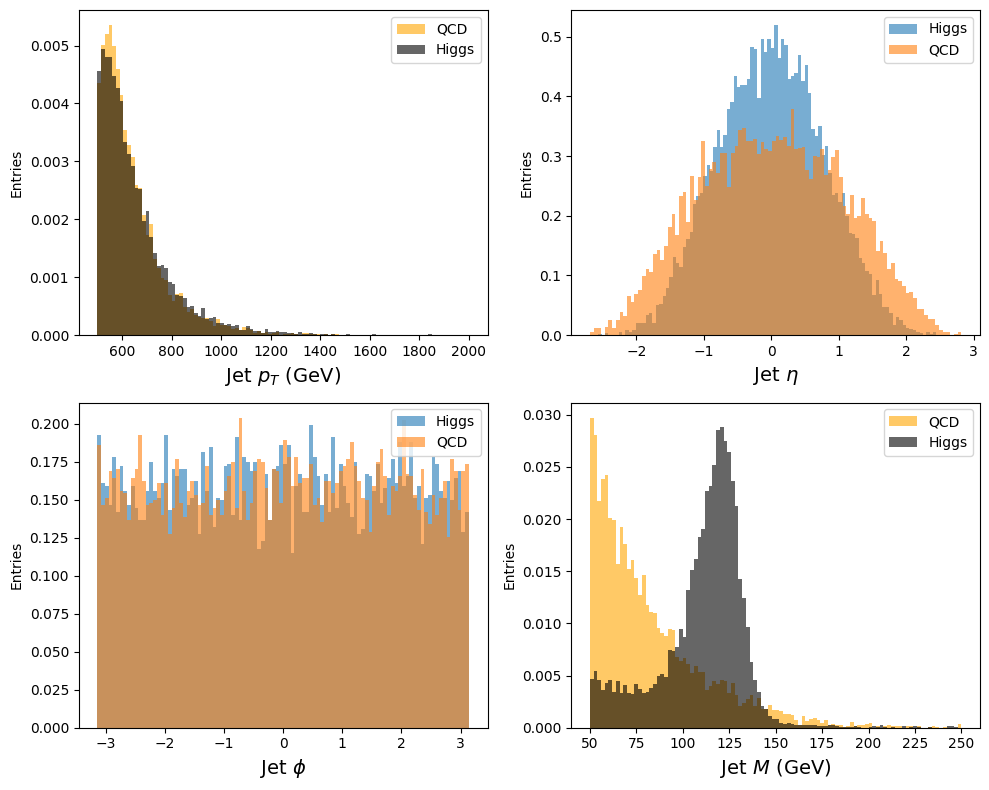

In [55]:
# %%
def get_leading_jet_obs(tree):
    pt   = tree["Jet.PT"].array()
    eta  = tree["Jet.Eta"].array()
    phi  = tree["Jet.Phi"].array()
    mass = tree["Jet.Mass"].array()
    tau  = tree["Jet.Tau[5]"].array()
    # keep only events with at least one FatJet
    has_jet = ak.num(pt) > 0
    pt, mass, eta, phi, tau = pt[has_jet], mass[has_jet], eta[has_jet], phi[has_jet], tau[has_jet]
    
    tau1, tau2, tau3, tau4 = ak.to_numpy(tau[:,0,0]), ak.to_numpy(tau[:,0,1]), ak.to_numpy(tau[:,0,2]), ak.to_numpy(tau[:,0,3])
    #storing the leading masses
    lead_pt   = ak.to_numpy(pt[:,0])
    lead_mass = ak.to_numpy(mass[:,0])
    lead_eta = ak.to_numpy(eta[:,0])
    lead_phi = ak.to_numpy(phi[:,0])

    tau21 = np.full_like(tau1, -1.0, dtype=float)
    np.divide(tau2, tau1, out=tau21, where=tau1 > 0)
    tau32 = np.full_like(tau2, -1.0, dtype=float)
    np.divide(tau3, tau2, out=tau32, where=tau2 > 0)
    tau43 = np.full_like(tau3, -1.0, dtype=float)
    np.divide(tau4, tau3, out=tau43, where=tau3 > 0)
    
    return lead_pt, lead_mass, lead_eta, lead_phi, tau21, tau32, tau43

jet_pt,  jet_mass, jet_eta, jet_phi , jet_tau21, jet_tau32, jet_tau43 = get_leading_jet_obs(tree_h)
jet_pt_qcd, jet_mass_qcd, jet_eta_qcd, jet_phi_qcd, jet_tau21_qcd, jet_tau32_qcd, jet_tau43_qcd = get_leading_jet_obs(tree_qcd)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].hist(jet_pt_qcd,bins=100, label = "QCD", density="True", alpha=0.6, range=(500,2000), color = "orange")
axes[0,0].hist(jet_pt,bins=100, label = "Higgs", density="True", alpha=0.6, range=(500,2000), color = "Black")
axes[0,0].set_xlabel(r'Jet $p_T$ (GeV)',fontsize=14)
axes[0,0].set_ylabel("Entries")
axes[0,0].legend()

axes[0,1].hist(jet_eta,bins=100, label = "Higgs", density="True", alpha=0.6)
axes[0,1].hist(jet_eta_qcd,bins=100, label = "QCD", density="True", alpha=0.6)
axes[0,1].set_xlabel(r'Jet ${\eta}$',fontsize=14)
axes[0,1].set_ylabel("Entries")
axes[0,1].legend()

axes[1,0].hist(jet_phi,bins=100, label = "Higgs", density="True", alpha=0.6)
axes[1,0].hist(jet_phi_qcd,bins=100, label = "QCD", density="True", alpha=0.6)
axes[1,0].set_xlabel(r'Jet ${\phi}$',fontsize=14)
axes[1,0].set_ylabel("Entries")
axes[1,0].legend()

axes[1,1].hist(jet_mass_qcd,bins=100, label = "QCD", density="True", alpha=0.6, range=(50,250), color="orange")
axes[1,1].hist(jet_mass,bins=100, label = "Higgs", density="True", alpha=0.6, range=(50, 250), color = "black")
axes[1,1].set_xlabel(r'Jet $M$ (GeV)',fontsize=14)
axes[1,1].set_ylabel("Entries")
axes[1,1].legend()

plt.tight_layout()
plt.show()

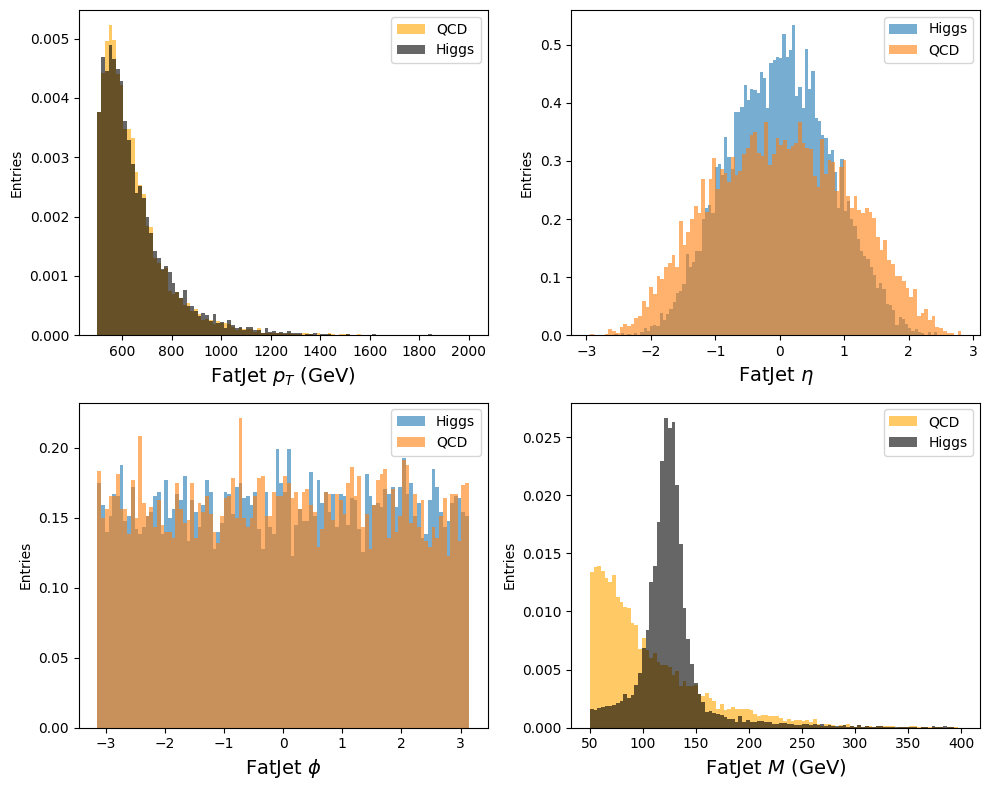

In [65]:
# %%
def get_leading_jet_obs(tree):
    pt   = tree["FatJet.PT"].array()
    eta  = tree["FatJet.Eta"].array()
    phi  = tree["FatJet.Phi"].array()
    mass = tree["FatJet.Mass"].array()
    tau  = tree["FatJet.Tau[5]"].array()
    # keep only events with at least one FatJet
    has_jet = ak.num(pt) > 0
    pt, mass, eta, phi, tau = pt[has_jet], mass[has_jet], eta[has_jet], phi[has_jet], tau[has_jet]
    
    tau1, tau2, tau3, tau4 = ak.to_numpy(tau[:,0,0]), ak.to_numpy(tau[:,0,1]), ak.to_numpy(tau[:,0,2]), ak.to_numpy(tau[:,0,3])
    #storing the leading masses
    lead_pt   = ak.to_numpy(pt[:,0])
    lead_mass = ak.to_numpy(mass[:,0])
    lead_eta = ak.to_numpy(eta[:,0])
    lead_phi = ak.to_numpy(phi[:,0])

    tau21 = np.full_like(tau1, -1.0, dtype=float)
    np.divide(tau2, tau1, out=tau21, where=tau1 > 0)
    tau32 = np.full_like(tau2, -1.0, dtype=float)
    np.divide(tau3, tau2, out=tau32, where=tau2 > 0)
    tau43 = np.full_like(tau3, -1.0, dtype=float)
    np.divide(tau4, tau3, out=tau43, where=tau3 > 0)

    return lead_pt, lead_mass, lead_eta, lead_phi, tau21, tau32, tau43


jet_pt,  jet_mass, jet_eta, jet_phi , fat_jet_tau21, jet_tau32, jet_tau43 = get_leading_jet_obs(tree_h)
jet_pt_qcd, jet_mass_qcd, jet_eta_qcd, jet_phi_qcd, fatjet_tau21_qcd, jet_tau32_qcd, jet_tau43_qcd = get_leading_jet_obs(tree_qcd)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].hist(jet_pt_qcd,bins=100, label = "QCD", density="True", alpha=0.6, range=(500,2000), color = "orange")
axes[0,0].hist(jet_pt,bins=100, label = "Higgs", density="True", alpha=0.6, range=(500,2000), color = "Black")
axes[0,0].set_xlabel(r'FatJet $p_T$ (GeV)',fontsize=14)
axes[0,0].set_ylabel("Entries")
axes[0,0].legend()

axes[0,1].hist(jet_eta,bins=100, label = "Higgs", density="True", alpha=0.6)
axes[0,1].hist(jet_eta_qcd,bins=100, label = "QCD", density="True", alpha=0.6)
axes[0,1].set_xlabel(r'FatJet ${\eta}$',fontsize=14)
axes[0,1].set_ylabel("Entries")
axes[0,1].legend()

axes[1,0].hist(jet_phi,bins=100, label = "Higgs", density="True", alpha=0.6)
axes[1,0].hist(jet_phi_qcd,bins=100, label = "QCD", density="True", alpha=0.6)
axes[1,0].set_xlabel(r'FatJet ${\phi}$',fontsize=14)
axes[1,0].set_ylabel("Entries")
axes[1,0].legend()

axes[1,1].hist(jet_mass_qcd,bins=100, label = "QCD", density="True", alpha=0.6, range=(50,400), color="orange")
axes[1,1].hist(jet_mass,bins=100, label = "Higgs", density="True", alpha=0.6, range=(50, 400), color = "black")
axes[1,1].set_xlabel(r'FatJet $M$ (GeV)',fontsize=14)
axes[1,1].set_ylabel("Entries")
axes[1,1].legend()

plt.tight_layout()
plt.show()

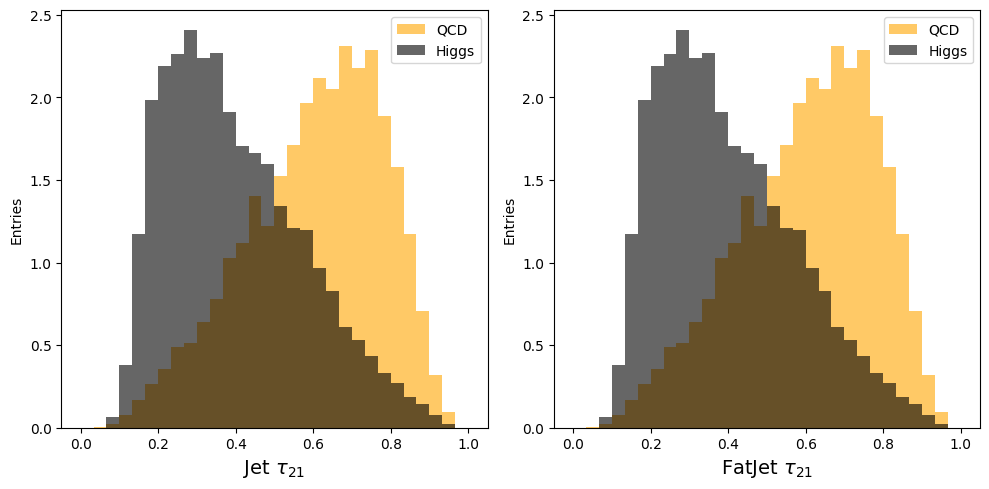

In [122]:

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].hist(jet_tau21_qcd,bins=30, label = "QCD", density="True", alpha=0.6, color = "orange", range=(0,1))
axes[0].hist(jet_tau21,bins=30, label = "Higgs", density="True", alpha=0.6,color = "Black", range=(0,1))
axes[0].set_xlabel(r'Jet ${\tau}_{21}$',fontsize=14)
axes[0].set_ylabel("Entries")
axes[0].legend()

axes[1].hist(fatjet_tau21_qcd,bins=30, label = "QCD", density="True", alpha=0.6, color = "orange",range=(0,1))
axes[1].hist(fat_jet_tau21,bins=30, label = "Higgs", density="True", alpha=0.6,color = "Black",range=(0,1))
axes[1].set_xlabel(r'FatJet ${\tau}_{21}$',fontsize=14)
axes[1].set_ylabel("Entries")
axes[1].legend()

plt.tight_layout()
plt.show()

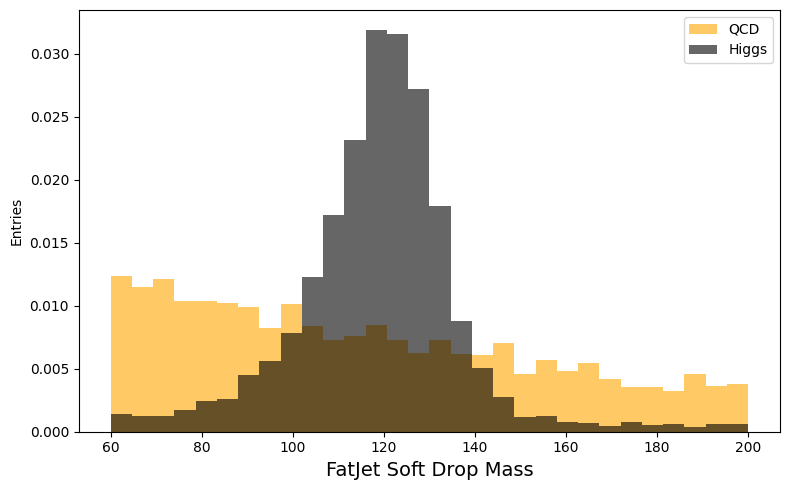

In [120]:
fat_p4 = tree_h["FatJet.SoftDroppedP4[5]"].array()
fat_p4_qcd = tree_qcd["FatJet.SoftDroppedP4[5]"].array()

fatmass_h = np.zeros(len(fat_p4))
fatmass_qcd = np.zeros(len(fat_p4_qcd))

m_list = [fatmass_h, fatmass_qcd]
p4_list = [fat_p4,fat_p4_qcd]

for j in range(len(m_list)):
    for i in range(len(fat_p4)):
        v = p4_list[j][i,0,0]
        l = v.fE**2 - v.fP.fX**2 - v.fP.fY**2 - v.fP.fZ**2
        if l > 0:
            m2 = np.sqrt(l)
            m_list[j][i] = m2


plt.figure(figsize=(8, 5))
plt.hist(fatmass_qcd,bins=30, label = "QCD", density="True", alpha=0.6, color = "orange", range=(60,200))
plt.hist(fatmass_h,bins=30, label = "Higgs", density="True", alpha=0.6,color = "Black", range=(60, 200))
plt.xlabel(r'FatJet Soft Drop Mass',fontsize=14)
plt.ylabel("Entries")
plt.legend()
plt.tight_layout()
plt.show()


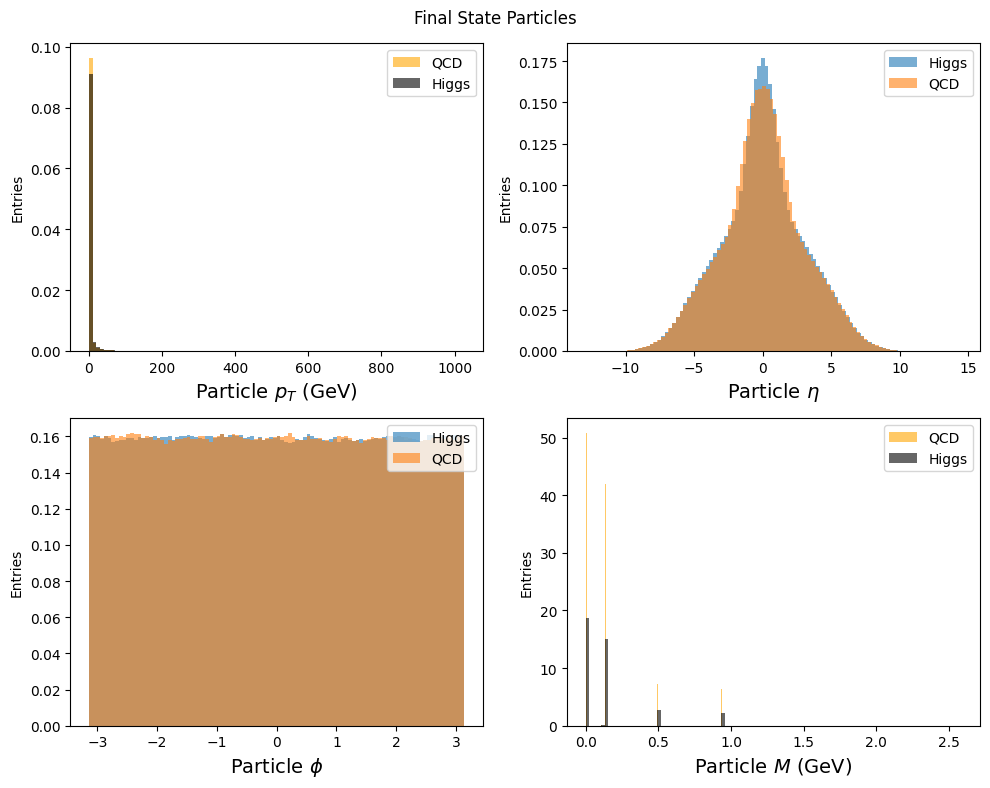

In [59]:
# %%
def get_leading_jet_obs(tree):
    pt   = ak.flatten(tree["Particle.PT"].array())
    eta  = ak.flatten(tree["Particle.Eta"].array())
    phi  = ak.flatten(tree["Particle.Phi"].array())
    mass = ak.flatten(tree["Particle.Mass"].array())

    # keep only events with at least one FatJet
    has_jet = (ak.flatten(tree["Particle.Status"] .array()) == 1) & (pt>0)
    final_pt, final_mass, final_eta, final_phi = pt[has_jet], mass[has_jet], eta[has_jet], phi[has_jet]

    return final_pt, final_mass, final_eta, final_phi

part_pt,  part_mass, part_eta, part_phi = get_leading_jet_obs(tree_h)
part_pt_qcd, part_mass_qcd, part_eta_qcd, part_phi_qcd = get_leading_jet_obs(tree_qcd)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Final State Particles")

axes[0,0].hist(part_pt_qcd,bins=100, label = "QCD", density=True, alpha=0.6, color = "orange")
axes[0,0].hist(part_pt,bins=100, label = "Higgs", density=True, alpha=0.6,color = "Black")
axes[0,0].set_xlabel(r'Particle $p_T$ (GeV)',fontsize=14)
axes[0,0].set_ylabel("Entries")
axes[0,0].legend()

axes[0,1].hist(part_eta,bins=100, label = "Higgs", density=True, alpha=0.6)
axes[0,1].hist(part_eta_qcd,bins=100, label = "QCD", density=True, alpha=0.6)
axes[0,1].set_xlabel(r'Particle ${\eta}$',fontsize=14)
axes[0,1].set_ylabel("Entries")
axes[0,1].legend()

axes[1,0].hist(part_phi,bins=100, label = "Higgs", density=True, alpha=0.6)
axes[1,0].hist(part_phi_qcd,bins=100, label = "QCD", density=True, alpha=0.6)
axes[1,0].set_xlabel(r'Particle ${\phi}$',fontsize=14)
axes[1,0].set_ylabel("Entries")
axes[1,0].legend()

axes[1,1].hist(part_mass_qcd,bins=100, label = "QCD", density=True, alpha=0.6, color="orange")
axes[1,1].hist(part_mass,bins=100, label = "Higgs", density=True, alpha=0.6, color = "black")
axes[1,1].set_xlabel(r'Particle $M$ (GeV)',fontsize=14)
axes[1,1].set_ylabel("Entries")
axes[1,1].legend()

plt.tight_layout()
plt.show()

### Observable Analysis

In [60]:
import pandas as pd

file = open("/home/sawini-jana/hep/pythia8316/coding/observables_6.5TeV.csv", "r", newline='')
df = pd.read_csv(file)

print(df['phi1'][0:5] + 1)
print(df.loc[10:12]['phi2'])

higgs = df[df.label==1][['phi1', 'phi2', 'phi3', 'phi4']].values
qcd = df[df.label==0][['phi1', 'phi2', 'phi3', 'phi4']].values
print(higgs)

0    1.159947
1    1.079685
2    1.202770
3    1.104462
4    1.091810
Name: phi1, dtype: float64
10    0.291277
11    0.259430
12    0.313157
Name: phi2, dtype: float64
[[0.159947   0.174616   0.114807   0.00207746]
 [0.0796851  0.353707   0.197437   0.0100032 ]
 [0.20277    0.0872575  0.0851813  0.00191447]
 ...
 [0.0773576  0.111952   0.0932356  0.00167774]
 [0.161563   0.155651   0.126257   0.00268837]
 [0.100725   0.198927   0.126993   0.00409492]]


In [61]:
qcd = qcd[int(len(qcd)/4):int(3*len(qcd)/4)]
print(len(higgs)+len(qcd))
print(len(qcd)/len(higgs)) #20:80 ratio

2061
0.739240506329114


In [62]:
import numpy as np

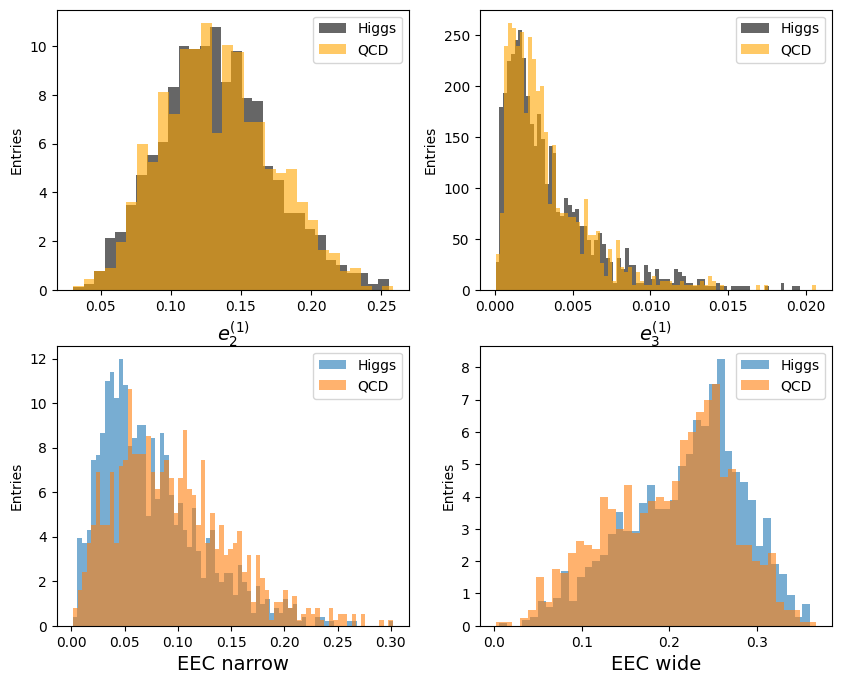

In [63]:
import matplotlib.pyplot as plt

#HIGGS
EECnarrow_h = higgs[:,0]
EECwide_h = higgs[:,1]
ecf2_h = higgs[:,2]
ecf3_h = higgs[:,3]

#QCD
EECnarrow_qcd = qcd[:,0]
EECwide_qcd = qcd[:,1]
ecf2_qcd = qcd[:,2]
ecf3_qcd = qcd[:,3]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].hist(ecf2_h, bins=30, density=True, alpha=0.6, label="Higgs", color="black")
axes[0,0].hist(ecf2_qcd, bins=30, density=True, alpha=0.6, label="QCD", color="orange")
axes[0,0].set_xlabel(r'$e_2^{(1)}$',fontsize=14)
axes[0,0].set_ylabel("Entries")
axes[0,0].legend()

axes[0,1].hist(ecf3_h, bins=80, density=True, alpha=0.6, label="Higgs", color="black")
axes[0,1].hist(ecf3_qcd, bins=80, density=True, alpha=0.6, label="QCD", color ="orange")
axes[0,1].set_xlabel(r'$e_3^{(1)}$',fontsize=14)
axes[0,1].set_ylabel("Entries")
axes[0,1].legend()

axes[1,0].hist(EECnarrow_h, bins=70, density=True, alpha=0.6, label="Higgs")
axes[1,0].hist(EECnarrow_qcd, bins=70, density=True, alpha=0.6, label="QCD")
axes[1,0].set_xlabel(r'EEC narrow',fontsize=14)
axes[1,0].set_ylabel("Entries")
axes[1,0].legend()

axes[1,1].hist(EECwide_h, bins=40, density=True, alpha=0.6, label="Higgs")
axes[1,1].hist(EECwide_qcd, bins=40, density=True, alpha=0.6, label="QCD")
axes[1,1].set_xlabel(r'EEC wide',fontsize=14)
axes[1,1].set_ylabel("Entries")
axes[1,1].legend()

plt.show()